# NLP-Based Content Recommendation for E-commerce Products

## Objective
This notebook builds a simple content-based recommendation system using product descriptions from the Online Retail dataset.

The goal is to represent products through text features and recommend similar items based on description similarity.


## Why this matters
Unlike basket co-occurrence recommendation, content-based recommendation does not rely on transaction co-purchase history. This makes it useful for:

- cold-start items,
- catalog exploration,
- product discovery,
- recommendation scenarios with limited behavioral data.


## Approach
The pipeline uses:
1. product catalog construction,
2. text cleaning,
3. TF-IDF vectorization,
4. cosine similarity,
5. top-N similar product retrieval.

# Preparation

## Import

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Load data

In [2]:
df = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={"stockcode": str, "customer_id": str},
    low_memory=False
)

df.head()

,invoice_no,stockcode,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet,is_cancellation,sales_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010,False,30.0


## Build product catalog

In [33]:
product_catalog_raw = (
    df.groupby(["stockcode", "description"], as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("sales_amount", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
)

product_catalog_raw.head()

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
0,10002,INFLATABLE POLITICAL GLOBE,8624,6761.52,297,164
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26,23
2,10109,BENDY COLOUR PENCILS,4,1.68,1,1
3,10120,DOGGY RUBBER,664,139.44,62,52
4,10123C,HEARTS WRAPPING TAPE,632,229.36,46,39


In [34]:
product_catalog = (
    product_catalog_raw
    .sort_values(["stockcode", "total_revenue"], ascending=[True, False])
    .groupby("stockcode", as_index=False)
    .first()
)

product_catalog.head()

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
0,10002,INFLATABLE POLITICAL GLOBE,8624,6761.52,297,164
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26,23
2,10109,BENDY COLOUR PENCILS,4,1.68,1,1
3,10120,DOGGY RUBBER,664,139.44,62,52
4,10123C,HEARTS WRAPPING TAPE,632,229.36,46,39


## Inspect catalog size

In [5]:
product_catalog.head()

,stockcode,description,total_quantity,total_revenue,total_orders,unique_customers
0,10002,INFLATABLE POLITICAL GLOBE,8624,6761.52,297,164
1,10080,GROOVY CACTUS INFLATABLE,303,124.61,26,23
2,10109,BENDY COLOUR PENCILS,4,1.68,1,1
3,10120,DOGGY RUBBER,664,139.44,62,52
4,10123C,HEARTS WRAPPING TAPE,632,229.36,46,39


## Check missing descriptions

In [7]:
product_catalog["description"].isna().sum()

0

## Basic text cleaning function

In [8]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

## Apply text cleaning

In [9]:
product_catalog["description_clean"] = product_catalog["description"].apply(clean_text)
product_catalog[["stockcode", "description", "description_clean"]].head(10)

,stockcode,description,description_clean
0,10002,INFLATABLE POLITICAL GLOBE,inflatable political globe
1,10080,GROOVY CACTUS INFLATABLE,groovy cactus inflatable
2,10109,BENDY COLOUR PENCILS,bendy colour pencils
3,10120,DOGGY RUBBER,doggy rubber
4,10123C,HEARTS WRAPPING TAPE,hearts wrapping tape
5,10123G,ARMY CAMO WRAPPING TAPE,army camo wrapping tape
6,10124A,SPOTS ON RED BOOKCOVER TAPE,spots on red bookcover tape
7,10124G,ARMY CAMO BOOKCOVER TAPE,army camo bookcover tape
8,10125,MINI FUNKY DESIGN TAPES,mini funky design tapes
9,10133,COLOURING PENCILS BROWN TUBE,colouring pencils brown tube


## Remove empty descriptions

In [10]:
product_catalog = product_catalog[product_catalog["description_clean"] != ""].copy()
product_catalog.shape

(5315, 7)

In [35]:
invalid_descriptions = {
    "manual",
    "discount",
    "postage",
    "bank charges",
    "samples",
    "adjust",
    "adjustment"
}

product_catalog = product_catalog[
    ~product_catalog["description_clean"].isin(invalid_descriptions)
].copy()

product_catalog = product_catalog[
    product_catalog["description_clean"].str.len() > 3
].copy()

product_catalog.shape

KeyError: 'description_clean'

## Optional inspection of frequent words

In [11]:
all_words = " ".join(product_catalog["description_clean"]).split()
word_freq = pd.Series(all_words).value_counts()

word_freq.head(20)

pink         472
set          458
blue         363
red          301
of           288
heart        286
vintage      271
glass        233
white        230
bag          203
christmas    192
candle       178
flower       176
box          173
design       171
3            171
rose         163
metal        154
small        152
black        149
Name: count, dtype: int64

## Plot top words

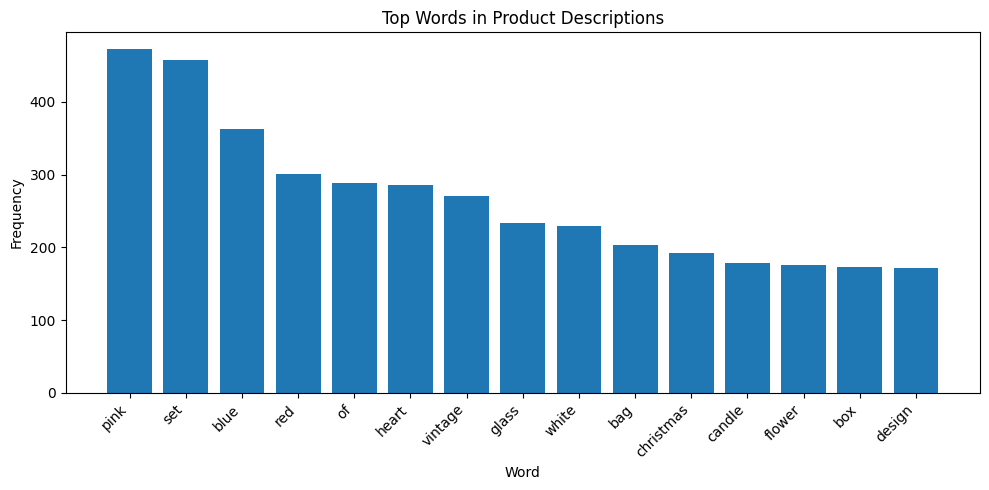

In [12]:
top_words = word_freq.head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_words.index, top_words.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top Words in Product Descriptions")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## TF-IDF vectorization

In [14]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(product_catalog["description_clean"])

tfidf_matrix.shape

(5315, 3000)

## Inspect feature names

In [15]:
feature_names = tfidf.get_feature_names_out()
feature_names[:30]

array(['10', '11', '11 pc', '12', '12 blue', '12 colour', '12 mini',
       '12 pencils', '12 pink', '12 red', '12 vintage', '16',
       '16 vintage', '20', '20 napkins', '2010', '24', '30cm', '36',
       '36 colour', '36 doilies', '36 pencils', '3d', '3d sheet',
       '3d stickers', '40', '42', '42 neckl', '45cm', '50'], dtype=object)

## Compute cosine similarity

In [16]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape

(5315, 5315)

## Create index mappings

In [17]:
product_catalog = product_catalog.reset_index(drop=True)

index_to_stockcode = dict(product_catalog.reset_index()[["index", "stockcode"]].values)
stockcode_to_index = dict(product_catalog.reset_index()[["stockcode", "index"]].values)

stockcode_to_index[list(stockcode_to_index.keys())[0]]

0

## Define recommendation function

In [36]:
def recommend_similar_products(stockcode, product_df, similarity_matrix, stockcode_index_map, top_n=5):
    if stockcode not in stockcode_index_map:
        return pd.DataFrame(columns=["stockcode", "description", "similarity_score"])
    
    idx = stockcode_index_map[stockcode]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    seen_stockcodes = set([stockcode])  # exclude the target itself

    for rec_idx, score in sim_scores:
        rec_stockcode = product_df.iloc[rec_idx]["stockcode"]
        rec_description = product_df.iloc[rec_idx]["description"]

        if rec_stockcode in seen_stockcodes:
            continue

        seen_stockcodes.add(rec_stockcode)

        recommendations.append({
            "stockcode": rec_stockcode,
            "description": rec_description,
            "similarity_score": score
        })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

## Test recommendation on one product

In [19]:
sample_product = product_catalog.iloc[0]["stockcode"]
sample_product

'10002'

In [20]:
target_product_info = product_catalog[product_catalog["stockcode"] == sample_product][["stockcode", "description"]]
target_product_info

,stockcode,description
0,10002,INFLATABLE POLITICAL GLOBE


In [21]:
recommend_similar_products(
    stockcode=sample_product,
    product_df=product_catalog,
    similarity_matrix=cosine_sim,
    stockcode_index_map=stockcode_to_index,
    top_n=10
)

,stockcode,description,similarity_score
1,10080,GROOVY CACTUS INFLATABLE,0.0
2,10109,BENDY COLOUR PENCILS,0.0
3,10120,DOGGY RUBBER,0.0
4,10123C,HEARTS WRAPPING TAPE,0.0
5,10123G,ARMY CAMO WRAPPING TAPE,0.0
6,10124A,SPOTS ON RED BOOKCOVER TAPE,0.0
7,10124G,ARMY CAMO BOOKCOVER TAPE,0.0
8,10125,MINI FUNKY DESIGN TAPES,0.0
9,10133,COLOURING PENCILS BROWN TUBE,0.0
10,10134,COLOURING PENCILS BROWN TUBE,0.0


## Test recommendation on popular products

In [22]:
popular_products = (
    product_catalog.sort_values("total_revenue", ascending=False)
    [["stockcode", "description", "total_revenue"]]
    .head(10)
)

popular_products

,stockcode,description,total_revenue
1862,22423,REGENCY CAKESTAND 3 TIER,286486.30
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5309,M,Manual,152340.57
4725,85099B,JUMBO BAG RED RETROSPOT,136980.08
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17
5311,POST,POSTAGE,126563.04
3627,47566,PARTY BUNTING,103880.23
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33


## Example 1

In [23]:
example_stockcode_1 = popular_products.iloc[0]["stockcode"]

print("Target product:")
display(product_catalog[product_catalog["stockcode"] == example_stockcode_1][["stockcode", "description", "total_revenue"]])

print("\nRecommended similar products:")
display(
    recommend_similar_products(
        stockcode=example_stockcode_1,
        product_df=product_catalog,
        similarity_matrix=cosine_sim,
        stockcode_index_map=stockcode_to_index,
        top_n=10
    )
)

Target product:


,stockcode,description,total_revenue
1862,22423,REGENCY CAKESTAND 3 TIER,286486.3



Recommended similar products:


,stockcode,description,similarity_score
2283,22776,"CAKESTAND, 3 TIER, LOVEHEART",0.898546
2285,22776,SWEETHEART CAKESTAND 3 TIER,0.822372
2344,22828,REGENCY MIRROR WITH SHUTTERS,0.341499
2778,23163,REGENCY SUGAR TONGS,0.302449
2339,22824,3 TIER SWEETHEART GARDEN SHELF,0.245010
2791,23174,REGENCY SUGAR BOWL GREEN,0.244377
2790,23173,REGENCY TEAPOT ROSES,0.240076
1602,22215,CAKE STAND WHITE TWO TIER LACE,0.211358
2775,23160,REGENCY TEA SPOON,0.209722
2776,23161,REGENCY CAKE FORK,0.206415


## Example 2

In [24]:
example_stockcode_2 = popular_products.iloc[3]["stockcode"]

print("Target product:")
display(product_catalog[product_catalog["stockcode"] == example_stockcode_2][["stockcode", "description", "total_revenue"]])

print("\nRecommended similar products:")
display(
    recommend_similar_products(
        stockcode=example_stockcode_2,
        product_df=product_catalog,
        similarity_matrix=cosine_sim,
        stockcode_index_map=stockcode_to_index,
        top_n=10
    )
)

Target product:


,stockcode,description,total_revenue
5309,M,Manual,152340.57



Recommended similar products:


,stockcode,description,similarity_score
1,10080,GROOVY CACTUS INFLATABLE,0.0
2,10109,BENDY COLOUR PENCILS,0.0
3,10120,DOGGY RUBBER,0.0
4,10123C,HEARTS WRAPPING TAPE,0.0
5,10123G,ARMY CAMO WRAPPING TAPE,0.0
6,10124A,SPOTS ON RED BOOKCOVER TAPE,0.0
7,10124G,ARMY CAMO BOOKCOVER TAPE,0.0
8,10125,MINI FUNKY DESIGN TAPES,0.0
9,10133,COLOURING PENCILS BROWN TUBE,0.0
10,10134,COLOURING PENCILS BROWN TUBE,0.0


## Compare co-occurrence vs content-based style

In [25]:
cooccurrence = pd.read_csv(
    "../outputs/tables/product_cooccurrence.csv",
    dtype={"stockcode_x": str, "stockcode_y": str},
    low_memory=False
)

cooccurrence.head()

,stockcode_x,description_x,stockcode_y,description_y,cooccurrence_count
0,21733,RED HANGING HEART T-LIGHT HOLDER,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1153
1,82482,WOODEN PICTURE FRAME WHITE FINISH,82494L,WOODEN FRAME ANTIQUE WHITE,993
2,22469,HEART OF WICKER SMALL,22470,HEART OF WICKER LARGE,869
3,21231,SWEETHEART CERAMIC TRINKET BOX,21232,STRAWBERRY CERAMIC TRINKET BOX,817
4,21754,HOME BUILDING BLOCK WORD,21755,LOVE BUILDING BLOCK WORD,786


## Rebuild co-occurrence helper

In [26]:
left_map = cooccurrence[["stockcode_x", "stockcode_y", "cooccurrence_count"]].rename(
    columns={
        "stockcode_x": "source_product",
        "stockcode_y": "recommended_product"
    }
)

right_map = cooccurrence[["stockcode_y", "stockcode_x", "cooccurrence_count"]].rename(
    columns={
        "stockcode_y": "source_product",
        "stockcode_x": "recommended_product"
    }
)

cooccurrence_long = pd.concat([left_map, right_map], ignore_index=True)

cooccurrence_ranked = (
    cooccurrence_long.groupby(["source_product", "recommended_product"], as_index=False)
    ["cooccurrence_count"]
    .sum()
    .sort_values(["source_product", "cooccurrence_count"], ascending=[True, False])
)

cooccurrence_dict = {}
for source_product, sub_df in cooccurrence_ranked.groupby("source_product"):
    cooccurrence_dict[source_product] = sub_df["recommended_product"].tolist()

## Co-occurrence recommendation helper

In [27]:
def recommend_cooccurrence_products(stockcode, cooccurrence_mapping, product_df, top_n=5):
    rec_codes = cooccurrence_mapping.get(stockcode, [])[:top_n]
    
    rec_df = product_df[product_df["stockcode"].isin(rec_codes)][["stockcode", "description", "total_revenue"]].copy()
    rec_df["rank"] = rec_df["stockcode"].apply(lambda x: rec_codes.index(x) if x in rec_codes else 999)
    rec_df = rec_df.sort_values("rank").drop(columns="rank")
    
    return rec_df

## Side-by-side comparison example

In [28]:
comparison_stockcode = popular_products.iloc[0]["stockcode"]

print("Target product:")
display(product_catalog[product_catalog["stockcode"] == comparison_stockcode][["stockcode", "description", "total_revenue"]])

print("\nCo-occurrence recommendations:")
display(
    recommend_cooccurrence_products(
        stockcode=comparison_stockcode,
        cooccurrence_mapping=cooccurrence_dict,
        product_df=product_catalog,
        top_n=10
    )
)

print("\nContent-based recommendations:")
display(
    recommend_similar_products(
        stockcode=comparison_stockcode,
        product_df=product_catalog,
        similarity_matrix=cosine_sim,
        stockcode_index_map=stockcode_to_index,
        top_n=10
    )
)

Target product:


,stockcode,description,total_revenue
1862,22423,REGENCY CAKESTAND 3 TIER,286486.3



Co-occurrence recommendations:


,stockcode,description,total_revenue
2195,22699,TEACUP AND SAUCER REGENCY ROSES,566.70
2194,22699,ROSES REGENCY TEACUP AND SAUCER,33096.00
2190,22697,GREEN REGENCY TEACUP AND SAUCER,24191.59
2191,22697,TEACUP AND SAUCER REGENCY GREEN,472.50
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46
4750,85123A,CREAM HANGING HEART T-LIGHT HOLDER,155.35
2192,22698,PINK REGENCY TEACUP AND SAUCER,20444.69
2193,22698,TEACUP AND SAUCER REGENCY PINK,384.00
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17
1257,21843,RETRO SPOT CAKE STAND,15333.20



Content-based recommendations:


,stockcode,description,similarity_score
2283,22776,"CAKESTAND, 3 TIER, LOVEHEART",0.898546
2285,22776,SWEETHEART CAKESTAND 3 TIER,0.822372
2344,22828,REGENCY MIRROR WITH SHUTTERS,0.341499
2778,23163,REGENCY SUGAR TONGS,0.302449
2339,22824,3 TIER SWEETHEART GARDEN SHELF,0.245010
2791,23174,REGENCY SUGAR BOWL GREEN,0.244377
2790,23173,REGENCY TEAPOT ROSES,0.240076
1602,22215,CAKE STAND WHITE TWO TIER LACE,0.211358
2775,23160,REGENCY TEA SPOON,0.209722
2776,23161,REGENCY CAKE FORK,0.206415


## Build a recommendation export table

In [29]:
sample_export_products = popular_products["stockcode"].head(5).tolist()

export_rows = []

for stockcode in sample_export_products:
    target_desc = product_catalog.loc[product_catalog["stockcode"] == stockcode, "description"].values[0]
    
    recs = recommend_similar_products(
        stockcode=stockcode,
        product_df=product_catalog,
        similarity_matrix=cosine_sim,
        stockcode_index_map=stockcode_to_index,
        top_n=5
    )
    
    for rank, (_, rec_row) in enumerate(recs.iterrows(), start=1):
        export_rows.append({
            "target_stockcode": stockcode,
            "target_description": target_desc,
            "recommended_stockcode": rec_row["stockcode"],
            "recommended_description": rec_row["description"],
            "rank": rank,
            "similarity_score": rec_row["similarity_score"]
        })

content_recommendation_examples = pd.DataFrame(export_rows)
content_recommendation_examples.head(20)

,target_stockcode,target_description,recommended_stockcode,recommended_description,rank,similarity_score
0,22423,REGENCY CAKESTAND 3 TIER,22776,"CAKESTAND, 3 TIER, LOVEHEART",1,0.898546
1,22423,REGENCY CAKESTAND 3 TIER,22776,SWEETHEART CAKESTAND 3 TIER,2,0.822372
2,22423,REGENCY CAKESTAND 3 TIER,22828,REGENCY MIRROR WITH SHUTTERS,3,0.341499
3,22423,REGENCY CAKESTAND 3 TIER,23163,REGENCY SUGAR TONGS,4,0.302449
4,22423,REGENCY CAKESTAND 3 TIER,22824,3 TIER SWEETHEART GARDEN SHELF,5,0.245010
5,85123A,CREAM HANGING HEART T-LIGHT HOLDER,21733,RED HANGING HEART T-LIGHT HOLDER,1,0.802499
6,85123A,CREAM HANGING HEART T-LIGHT HOLDER,85123A,CREAM HANGING HEART T-LIGHT HOLDER,2,0.780254
7,85123A,CREAM HANGING HEART T-LIGHT HOLDER,22804,PINK HANGING HEART T-LIGHT HOLDER,3,0.704705
8,85123A,CREAM HANGING HEART T-LIGHT HOLDER,21814,HEART T-LIGHT HOLDER,4,0.684105
9,85123A,CREAM HANGING HEART T-LIGHT HOLDER,85118,HEART T-LIGHT HOLDER,5,0.684105


## Export results

In [30]:
product_catalog.to_csv("../outputs/tables/product_catalog_nlp.csv", index=False)
content_recommendation_examples.to_csv("../outputs/tables/content_based_recommendation_examples.csv", index=False)

## Optional: inspect vocabulary size

In [31]:
len(feature_names)

3000

## Optional: inspect top weighted terms for one product

In [32]:
def show_top_tfidf_terms(stockcode, product_df, tfidf_matrix, feature_names, stockcode_index_map, top_n=10):
    if stockcode not in stockcode_index_map:
        return pd.DataFrame(columns=["term", "weight"])
    
    idx = stockcode_index_map[stockcode]
    row = tfidf_matrix[idx].toarray().flatten()
    top_indices = row.argsort()[::-1][:top_n]
    
    return pd.DataFrame({
        "term": feature_names[top_indices],
        "weight": row[top_indices]
    })

show_top_tfidf_terms(
    stockcode=example_stockcode_1,
    product_df=product_catalog,
    tfidf_matrix=tfidf_matrix,
    feature_names=feature_names,
    stockcode_index_map=stockcode_to_index,
    top_n=10
)

,term,weight
0,cakestand tier,0.550261
1,cakestand,0.550261
2,tier,0.449234
3,regency,0.438879
4,fruit bowl,0.000000
5,frying pan,0.000000
6,frying,0.000000
7,frutti keyring,0.000000
8,frutti,0.000000
9,fruits,0.000000
